In [12]:
import numpy as np
import pandas as pd

dmdk = pd.read_csv('/Users/tefoboyze/glm-danish-mortality/data/dmdk.csv')  
dmdk['diabetes'] = dmdk['diabetes'].map({0: 'No', 1: 'Yes'})

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.families import Poisson, NegativeBinomial
from statsmodels.genmod.families.links import Log
from statsmodels.nonparametric.smoothers_lowess import lowess
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'axes.titleweight': 'bold',
})

print("All imports successful.")

All imports successful.


## Background

Diabetes is a chronic condition strongly linked to elevated mortality risk, through cardiovascular disease, kidney damage, and other complications. Using population-level mortality data from Denmark (1996–2015), stratified by age, sex, calendar period, and diabetes status, this project quantifies how much diabetes actually raises the risk of death, and estimates how many deaths in the Danish population over this 20-year window can be attributed to it.

## The Data

The dataset $\texttt{dmdk}$ contains aggregated mortality data for Denmark
over the period 1996–2015, broken down into subgroups defined by four
demographic variables:

- $\texttt{agegrp}$: age in 5-year bands, from 0 to 100 (20 levels)
- $\texttt{period}$: calendar period in 5-year bands (1996–2000, 2001–2005,
  2006–2010, 2011–2015)
- $\texttt{sex}$: male ($\texttt{M}$) or female ($\texttt{F}$)
- $\texttt{diabetes}$: diabetes status, coded as $\texttt{Yes}$ or $\texttt{No}$

For each subgroup, three further variables summarise mortality experience:

- $\texttt{deaths}$: the total number of deaths observed in that subgroup
- $\texttt{pyar}$: person-years at risk, i.e. the total follow-up time
  accumulated by individuals in that subgroup
- $\texttt{age}$: the average age within the subgroup, included as a
  continuous alternative to $\texttt{agegrp}$

Because the data is aggregated rather than individual-level, the natural
unit of analysis is the subgroup rate $\lambda_i = D_i / Y_i$, where $D_i$
is $\texttt{deaths}$ and $Y_i$ is $\texttt{pyar}$ in subgroup $i$. This
motivates modelling $\texttt{deaths}$ as a Poisson (or negative binomial)
count with $\log(\texttt{pyar})$ as an offset, rather than working with the
raw rates directly.

### Empirical death rates

Before fitting any model, it is useful to look directly at the raw,
model-free death rates across the four demographic dimensions. For each
subgroup $i$, the empirical rate is defined as

$$
\text{Rate}_i = \frac{D_i + 0.5}{Y_i}
$$

where $D_i$ is $\texttt{deaths}$ and $Y_i$ is $\texttt{pyar}$. The $0.5$
offset is a continuity correction: without it, any subgroup with zero
observed deaths would have a rate of exactly zero, which is both
undefined on a log scale and misleading, since zero deaths in a small
subgroup can easily happen by chance rather than reflecting a true zero
risk. Adding $0.5$ stabilises the rate in these small-count subgroups
without materially affecting the larger ones.

Plotting $\texttt{age}$ against $\text{Rate}_i$ (log scale), split by
$\texttt{sex}$ and coloured by $\texttt{diabetes}$, with a separate line
per $\texttt{period}$, gives a first look at the patterns any model will
need to capture.

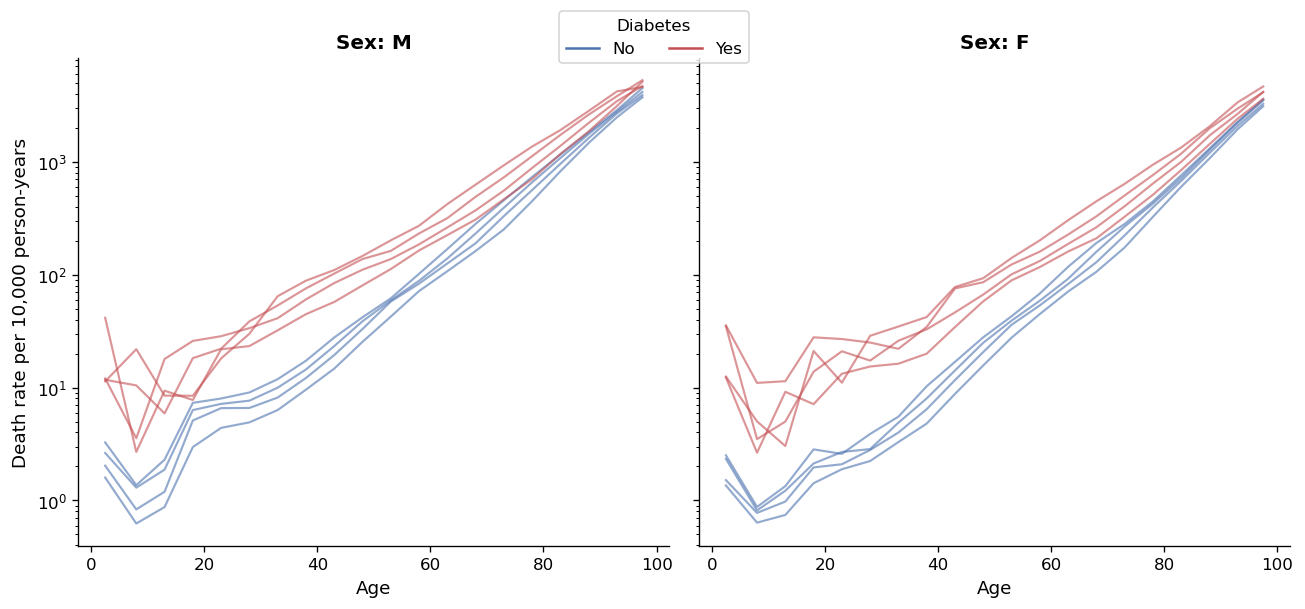

In [8]:
dmdk['rate_per_10000'] = 10000 * (dmdk['deaths'] + 0.5) / dmdk['pyar']

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
colors = {'No': '#4C72B0', 'Yes': '#C44E52'}

for ax, sex in zip(axes, ['M', 'F']):
    sub = dmdk[dmdk['sex'] == sex]
    for diab in ['No', 'Yes']:
        for period in sorted(sub['period'].unique()):
            line = sub[(sub['diabetes'] == diab) & (sub['period'] == period)].sort_values('age')
            ax.plot(line['age'], line['rate_per_10000'], color=colors[diab], alpha=0.6, linewidth=1.3)
    ax.set_yscale('log')
    ax.set_title(f"Sex: {sex}")
    ax.set_xlabel('Age')

axes[0].set_ylabel('Death rate per 10,000 person-years')
handles = [plt.Line2D([0], [0], color=colors[d], label=d) for d in ['No', 'Yes']]
fig.legend(handles=handles, title='Diabetes', loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.show()

Several patterns are visible:

- **Age.** Death rates follow a classic "bathtub" shape: relatively high
  in infancy, falling to a minimum around age 8-10, then rising
  steadily and steeply through adulthood into old age.
- **Sex.** Male death rates sit slightly above female rates for most of
  the age range, though the gap is small compared to the age effect.
- **Diabetes.** Individuals with diabetes have consistently higher death
  rates than those without, at every age and for both sexes. The gap is
  proportionally largest at younger ages and narrows (though does not
  disappear) at older ages, suggesting diabetes' relative impact on
  mortality risk may not be constant across the age range.
- **Period.** The period-specific lines are noisy and cross each other
  at young ages, where death counts are small and so rates are volatile,
  but become smooth and tightly bunched at older ages, where death
  counts are large.

### Modelling death rates in the general population

Before considering diabetes, it is worth establishing a baseline model
for mortality in the general (non-diabetic) population, using
$\texttt{agegrp}$, $\texttt{period}$, and $\texttt{sex}$ as predictors.
Since the response is a count ($\texttt{deaths}$) observed over a known
exposure ($\texttt{pyar}$), a Poisson model with $\log(\texttt{pyar})$ as
an offset is a natural choice, so that each coefficient is interpretable
as a log rate ratio. The Poisson assumption that variance equals the
mean ($\phi = 1$) may not hold for mortality data, a point revisited
later.

**Continuous vs. categorical age.** Figure 1 showed a clearly non-linear,
bathtub-shaped age pattern. Replacing the 20-level factor
$\texttt{agegrp}$ with the single numeric variable $\texttt{age}$ would
simplify the model considerably (one parameter instead of nineteen), but
risks a poor fit if the true age effect is not linear on the log scale.

Let $M_1$ denote the simpler model with $\texttt{age}$ entered linearly:

$$
M_1: \quad \log(\mu_i) = \eta_i + \log(\texttt{pyar}_i), \qquad i = 1, \dots, 160,
$$

where

$$
\eta_i = \beta_0 + \beta_{\texttt{sex}} \cdot \mathbf{1}(\texttt{sex}_i = \texttt{M})
+ \sum_{k=2}^{4} \beta_{p_k} \cdot \mathbf{1}(\texttt{period}_i = k)
+ \gamma \cdot \texttt{age}_i,
$$

with $\beta_0$ the log rate for the reference group (female, period 1),
$\beta_{\texttt{sex}}$ the adjustment for males relative to females,
$\beta_{p_2}, \beta_{p_3}, \beta_{p_4}$ the adjustments for periods 2-4
relative to period 1, and $\gamma$ a single linear slope on age.

Let $M_2$ denote the larger model with $\texttt{agegrp}$ entered as a factor:

$$
M_2: \quad \log(\mu_i) = \eta_i^{*} + \log(\texttt{pyar}_i), \qquad i = 1, \dots, 160,
$$

where

$$
\eta_i^{*} = \beta_0 + \beta_{\texttt{sex}} \cdot \mathbf{1}(\texttt{sex}_i = \texttt{M})
+ \sum_{k=2}^{4} \beta_{p_k} \cdot \mathbf{1}(\texttt{period}_i = k)
+ \sum_{j=2}^{20} \alpha_j \cdot \mathbf{1}(\texttt{agegrp}_i = j),
$$

with $\alpha_j$ a separate parameter for each of the 19 non-reference age
groups.

Since $M_1$ can be recovered from $M_2$ by imposing the linear
constraint $\alpha_j = \gamma(x_j - x_{\text{ref}})$, where $x_j$ is the
mean age of group $j$, $M_1$ is nested in $M_2$. This allows a
likelihood ratio test with

$$
H_0: M_1 \text{ is the true model} \qquad \text{vs.} \qquad H_1: M_2 \text{ is the true model}.
$$

In [13]:
# creating a subset for the general population (without diabetes)
dmdk_general = dmdk[dmdk['diabetes'] == 'No'].copy()

# M1: age as a single numeric (linear) term
M1 = smf.glm(formula='deaths ~ age + period + sex', data=dmdk_general,
             family=sm.families.Poisson(),
             offset=np.log(dmdk_general['pyar'])).fit()

# M2: agegrp as a 20-level factor
M2 = smf.glm(formula='deaths ~ C(agegrp) + period + sex', data=dmdk_general,
             family=sm.families.Poisson(),
             offset=np.log(dmdk_general['pyar'])).fit()

In [15]:
M1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                 deaths   No. Observations:                  160
Model:                            GLM   Df Residuals:                      154
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -9007.1
Date:                Tue, 07 Jul 2026   Deviance:                       16506.
Time:                        16:47:30   Pearson chi2:                 2.40e+04
No. Iterations:                     7   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             -10.6836      0.006  -1744.098      0.000     -10.696     -10.672
period[T.2001-2005]    -0.0915      0.003    -32.488      0.000      -0.097      -0.086
period[T.2006-2010]    -0.2021      0.003    -70.369      0.000      -0.208      -0.196
period[T.2011-2015]    -0.3680      0.003   -130.947      0.000      -0.373      -0.362
sex[T.M]                0.3660      0.002    178.596      0.000       0.362       0.370
age                     0.0985   7.38e-05   1334.812      0.000       0.098       0.099
=======================================================================================
"""

In [16]:
M2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                 deaths   No. Observations:                  160
Model:                            GLM   Df Residuals:                      136
Model Family:                 Poisson   Df Model:                           23
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3535.2
Date:                Tue, 07 Jul 2026   Deviance:                       5562.0
Time:                        16:47:56   Pearson chi2:                 5.54e+03
No. Iterations:                     8   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -8.4992      0.024   -356.277      0.000      -8.546      -8.452
C(agegrp)[T.11-15]     -0.5142      0.042    -12.386      0.000      -0.596      -0.433
C(agegrp)[T.16-20]      0.5426      0.031     17.400      0.000       0.481       0.604
C(agegrp)[T.21-25]      0.7192      0.030     24.122      0.000       0.661       0.778
C(agegrp)[T.26-30]      0.8484      0.029     29.364      0.000       0.792       0.905
C(agegrp)[T.31-35]      1.1512      0.027     42.012      0.000       1.098       1.205
C(agegrp)[T.36-40]      1.5725      0.026     60.127      0.000       1.521       1.624
C(agegrp)[T.41-45]      2.0663      0.025     81.761      0.000       2.017       2.116
C(agegrp)[T.46-50]      2.5801      0.025    104.443      0.000       2.532       2.629
C(agegrp)[T.51-55]      3.0579      0.024    125.440      0.000       3.010       3.106
C(agegrp)[T.56-60]      3.5005      0.024    144.611      0.000       3.453       3.548
C(agegrp)[T.6-10]      -0.8757      0.047    -18.799      0.000      -0.967      -0.784
C(agegrp)[T.61-65]      3.9558      0.024    164.185      0.000       3.909       4.003
C(agegrp)[T.66-70]      4.4216      0.024    184.103      0.000       4.375       4.469
C(agegrp)[T.71-75]      4.9181      0.024    205.245      0.000       4.871       4.965
C(agegrp)[T.76-80]      5.4427      0.024    227.535      0.000       5.396       5.490
C(agegrp)[T.81-85]      5.9785      0.024    250.136      0.000       5.932       6.025
C(agegrp)[T.86-90]      6.5244      0.024    272.864      0.000       6.478       6.571
C(agegrp)[T.91-95]      7.0761      0.024    294.876      0.000       7.029       7.123
C(agegrp)[T.96-100]     7.5365      0.025    307.187      0.000       7.488       7.585
period[T.2001-2005]    -0.0933      0.003    -33.101      0.000      -0.099      -0.088
period[T.2006-2010]    -0.2038      0.003    -70.905      0.000      -0.209      -0.198
period[T.2011-2015]    -0.3685      0.003   -130.930      0.000      -0.374      -0.363
sex[T.M]                0.3811      0.002    185.041      0.000       0.377       0.385
=======================================================================================
"""

### Comparing $M_1$ and $M_2$: likelihood ratio test

Having printed the summaries of $M_1$ and $M_2$ above, we can now
formally test whether the added flexibility of $\texttt{agegrp}$ over
$\texttt{age}$ is justified. Since $M_1$ is nested in $M_2$, the
likelihood ratio test statistic is

$$
\Lambda = 2 \left( \ell(M_2) - \ell(M_1) \right) \ \sim \ \chi^2_{d},
$$

where $\ell(\cdot)$ denotes the log-likelihood of each model and $d$ is
the difference in the number of parameters between $M_2$ and $M_1$
(here $d = 18$, since $M_2$ replaces the single slope $\gamma$ with 19
separate $\alpha_j$ parameters). Under $H_0$, $\Lambda$ is
asymptotically chi-squared distributed with $d$ degrees of freedom,
which gives a p-value for the test.

In [18]:
# Likelihood ratio test: M1 nested in M2
LR_stat = 2 * (M2.llf - M1.llf)
df_diff = M2.df_model - M1.df_model
p_value = stats.chi2.sf(LR_stat, df_diff)

print(f"LR statistic: {LR_stat:.2f}, df = {df_diff:.0f}, p-value = {p_value:.7g}")

LR statistic: 10943.90, df = 18, p-value = 0


Under a 5% significance level, the p-value is far smaller than 0.05, so there is sufficient evidence to reject the null
hypothesis $H_0$. This suggests the $\texttt{agegrp}$ model $M_2$ fits
the data significantly better. Using $M_1$ would fail to capture the
non-linear pattern of mortality.

In [19]:
# Rate ratio for sex, from M2
# statsmodels uses 'F' as the reference level for sex (alphabetical default)
beta_M = M2.params['sex[T.M]']
se_M = M2.bse['sex[T.M]']

RR_female_vs_male = np.exp(-beta_M)
CI_female_vs_male = sorted(np.exp([-beta_M - 1.96*se_M, -beta_M + 1.96*se_M]))

print(f"Female-to-male rate ratio: {RR_female_vs_male:.4f}")
print(f"95% CI: ({CI_female_vs_male[0]:.4f}, {CI_female_vs_male[1]:.4f})")

Female-to-male rate ratio: 0.6831
95% CI: (0.6803, 0.6859)


The estimated female-to-male rate ratio is 0.6831. This means that,
after adjusting for age and period, women's death rates are
approximately 68.31% of men's death rates, or about 31.69% lower than
men's. The 95% confidence interval is (0.6803, 0.6859), which does not
include 1, confirming that this difference is statistically significant.

### Effect of diabetes on death rates

Having established a baseline model for the general population, we now
fit a model to the full dataset, adding $\texttt{diabetes}$ as a
predictor alongside $\texttt{agegrp}$, $\texttt{period}$, and
$\texttt{sex}$:

$$
M_3: \quad \log(\mu_i) = \beta_0
+ \sum_{j=2}^{20} \alpha_j \cdot \mathbf{1}(\texttt{agegrp}_i = j)
+ \sum_{k=2}^{4} \beta_{p_k} \cdot \mathbf{1}(\texttt{period}_i = k)
+ \beta_{\texttt{sex}} \cdot \mathbf{1}(\texttt{sex}_i = \texttt{M})
+ \beta_{\texttt{d}} \cdot \mathbf{1}(\texttt{diabetes}_i = \texttt{Yes})
+ \log(\texttt{pyar}_i).
$$

Before interpreting $M_3$, it is worth checking for influential
observations, subgroups whose presence disproportionately affects the
fitted model. Cook's distance is a standard diagnostic for this: it
measures how much the fitted values across the whole model would change
if a given observation were removed, combining both the size of its
residual and its leverage.

In [20]:
# fitting the full model on the whole dataset
M3 = smf.glm(formula='deaths ~ C(agegrp) + period + sex + diabetes', data=dmdk,
             family=sm.families.Poisson(), offset=np.log(dmdk['pyar'])).fit()

M3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                 deaths   No. Observations:                  320
Model:                            GLM   Df Residuals:                      295
Model Family:                 Poisson   Df Model:                           24
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8437.6
Date:                Tue, 07 Jul 2026   Deviance:                       14301.
Time:                        17:05:07   Pearson chi2:                 1.56e+04
No. Iterations:                    10   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -8.4826      0.024   -356.159      0.000      -8.529      -8.436
C(agegrp)[T.11-15]     -0.5017      0.041    -12.163      0.000      -0.583      -0.421
C(agegrp)[T.16-20]      0.5514      0.031     17.756      0.000       0.491       0.612
C(agegrp)[T.21-25]      0.7328      0.030     24.705      0.000       0.675       0.791
C(agegrp)[T.26-30]      0.8711      0.029     30.354      0.000       0.815       0.927
C(agegrp)[T.31-35]      1.1838      0.027     43.515      0.000       1.131       1.237
C(agegrp)[T.36-40]      1.6131      0.026     62.093      0.000       1.562       1.664
C(agegrp)[T.41-45]      2.1160      0.025     84.223      0.000       2.067       2.165
C(agegrp)[T.46-50]      2.6281      0.025    106.884      0.000       2.580       2.676
C(agegrp)[T.51-55]      3.1033      0.024    127.804      0.000       3.056       3.151
C(agegrp)[T.56-60]      3.5442      0.024    146.938      0.000       3.497       3.591
C(agegrp)[T.6-10]      -0.8732      0.046    -18.795      0.000      -0.964      -0.782
C(agegrp)[T.61-65]      3.9934      0.024    166.276      0.000       3.946       4.040
C(agegrp)[T.66-70]      4.4451      0.024    185.600      0.000       4.398       4.492
C(agegrp)[T.71-75]      4.9276      0.024    206.133      0.000       4.881       4.974
C(agegrp)[T.76-80]      5.4355      0.024    227.692      0.000       5.389       5.482
C(agegrp)[T.81-85]      5.9567      0.024    249.673      0.000       5.910       6.004
C(agegrp)[T.86-90]      6.4951      0.024    272.119      0.000       6.448       6.542
C(agegrp)[T.91-95]      7.0425      0.024    294.073      0.000       6.996       7.089
C(agegrp)[T.96-100]     7.5023      0.024    306.908      0.000       7.454       7.550
period[T.2001-2005]    -0.0999      0.003    -37.846      0.000      -0.105      -0.095
period[T.2006-2010]    -0.2235      0.003    -83.415      0.000      -0.229      -0.218
period[T.2011-2015]    -0.3944      0.003   -151.347      0.000      -0.400      -0.389
sex[T.M]                0.3758      0.002    197.450      0.000       0.372       0.380
diabetes[T.Yes]         0.5511      0.003    206.965      0.000       0.546       0.556
=======================================================================================
"""

In [21]:
# calculating Cook's distance
influence = M3.get_influence()
dmdk['cooks_d'] = influence.cooks_distance[0]

# finding the top 3 observations
top3 = dmdk.sort_values('cooks_d', ascending=False).head(3)
top3

,diabetes,sex,agegrp,period,deaths,pyar,age,cooks_d
155,No,F,91-95,2011-2015,19852,102464.212868,93.0,9.415763
151,No,F,86-90,2011-2015,23985,224789.106092,88.0,5.691254
159,No,F,96-100,2011-2015,7020,22697.746064,97.5,3.729310


The Cook's distance values above already identified the three most
influential observations numerically. Plotting Cook's distance against
observation index makes this visually clear and shows how much they
stand out from the rest of the data.

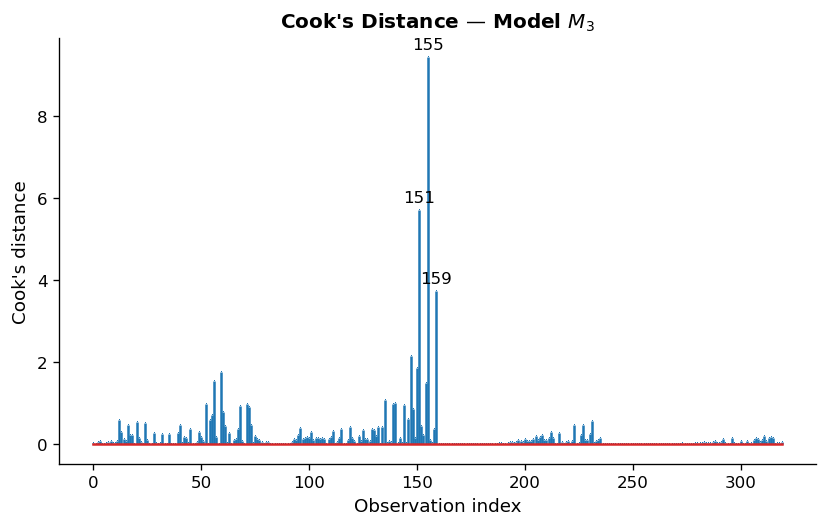

In [26]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.stem(np.arange(len(dmdk)), dmdk['cooks_d'], markerfmt=",")

top3_idx = dmdk['cooks_d'].sort_values(ascending=False).head(3).index
for idx in top3_idx:
    ax.annotate(str(idx), (idx, dmdk['cooks_d'][idx]),
                textcoords="offset points", xytext=(0, 5), ha='center')

ax.set_xlabel("Observation index")
ax.set_ylabel("Cook's distance")
ax.set_title("Cook's Distance — Model $M_3$")
plt.tight_layout()
plt.show()

### Accounting for overdispersion: quasi-Poisson

The plain Poisson model assumes $\text{Var}(D_i \mid \mathbf{x}_i) = \mu_i$,
i.e. a fixed dispersion of $\phi = 1$. Mortality count data of this kind
often violates this assumption, since deaths are influenced by many
unmeasured sources of heterogeneity within each demographic subgroup
(comorbidities, socioeconomic factors, regional variation), causing the
true variance to exceed the mean. Fitting a plain Poisson model in this
setting produces the correct point estimates for $\beta$, but
understates the standard errors, since the model incorrectly assumes
$\phi = 1$.

The quasi-Poisson approach addresses this without changing the
distributional family: it fits the same Poisson mean structure by
quasi-likelihood, then estimates the dispersion parameter directly from
the data,

$$
\hat\phi = \frac{1}{n-p}\sum_{i=1}^n \frac{(D_i - \hat\mu_i)^2}{\hat\mu_i},
$$

and inflates all standard errors by $\sqrt{\hat\phi}$. This gives valid
inference (correct confidence intervals and test statistics) without
requiring a fully specified likelihood, which is why it is the
appropriate first step here, before moving to the negative binomial
model as a fully likelihood-based alternative.

`statsmodels` does not have a `quasipoisson` family by name, but the
equivalent is fitting `Poisson` and rescaling using the Pearson
chi-square dispersion estimate, via `.fit(scale='X2')`.

In [27]:
poisson_full = smf.glm(formula='deaths ~ sex + diabetes + C(agegrp) + period', data=dmdk,
                        family=sm.families.Poisson(),
                        offset=np.log(dmdk['pyar'])).fit(scale='X2')

print(f"Estimated dispersion (phi): {poisson_full.scale:.2f}")
poisson_full.summary()

Estimated dispersion (phi): 52.76


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                 deaths   No. Observations:                  320
Model:                            GLM   Df Residuals:                      295
Model Family:                 Poisson   Df Model:                           24
Link Function:                    Log   Scale:                          52.761
Method:                          IRLS   Log-Likelihood:                -159.92
Date:                Mon, 27 Jul 2026   Deviance:                       14301.
Time:                        21:19:59   Pearson chi2:                 1.56e+04
No. Iterations:                    12   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -8.4826      0.173    -49.033      0.000      -8.822      -8.144
sex[T.M]                0.3758      0.014     27.183      0.000       0.349       0.403
diabetes[T.Yes]         0.5511      0.019     28.493      0.000       0.513       0.589
C(agegrp)[T.11-15]     -0.5017      0.300     -1.674      0.094      -1.089       0.086
C(agegrp)[T.16-20]      0.5514      0.226      2.444      0.015       0.109       0.993
C(agegrp)[T.21-25]      0.7328      0.215      3.401      0.001       0.311       1.155
C(agegrp)[T.26-30]      0.8711      0.208      4.179      0.000       0.463       1.280
C(agegrp)[T.31-35]      1.1838      0.198      5.991      0.000       0.797       1.571
C(agegrp)[T.36-40]      1.6131      0.189      8.548      0.000       1.243       1.983
C(agegrp)[T.41-45]      2.1160      0.182     11.595      0.000       1.758       2.474
C(agegrp)[T.46-50]      2.6281      0.179     14.715      0.000       2.278       2.978
C(agegrp)[T.51-55]      3.1033      0.176     17.595      0.000       2.758       3.449
C(agegrp)[T.56-60]      3.5442      0.175     20.229      0.000       3.201       3.888
C(agegrp)[T.6-10]      -0.8732      0.337     -2.588      0.010      -1.535      -0.212
C(agegrp)[T.61-65]      3.9934      0.174     22.891      0.000       3.651       4.335
C(agegrp)[T.66-70]      4.4451      0.174     25.552      0.000       4.104       4.786
C(agegrp)[T.71-75]      4.9276      0.174     28.379      0.000       4.587       5.268
C(agegrp)[T.76-80]      5.4355      0.173     31.347      0.000       5.096       5.775
C(agegrp)[T.81-85]      5.9567      0.173     34.373      0.000       5.617       6.296
C(agegrp)[T.86-90]      6.4951      0.173     37.463      0.000       6.155       6.835
C(agegrp)[T.91-95]      7.0425      0.174     40.486      0.000       6.702       7.383
C(agegrp)[T.96-100]     7.5023      0.178     42.252      0.000       7.154       7.850
period[T.2001-2005]    -0.0999      0.019     -5.210      0.000      -0.138      -0.062
period[T.2006-2010]    -0.2235      0.019    -11.484      0.000      -0.262      -0.185
period[T.2011-2015]    -0.3944      0.019    -20.836      0.000      -0.432      -0.357
=======================================================================================
"""

Two diagnostic plots examine different aspects of model fit:

- **Structural part** - Pearson residuals against fitted values, which
  checks whether the mean structure is correctly specified.
- **Random part** - a scale-location plot: the square root of the
  absolute standardized Pearson residuals against fitted values, which
  checks whether the mean-variance relationship is correctly specified.
  A QQ plot is not used here, since it does not diagnose problems with
  the mean-variance relationship specifically, a flat QQ deviation can
  coexist with severe heteroskedasticity, and a skewed QQ plot doesn't
  by itself indicate which part of the model is misspecified.

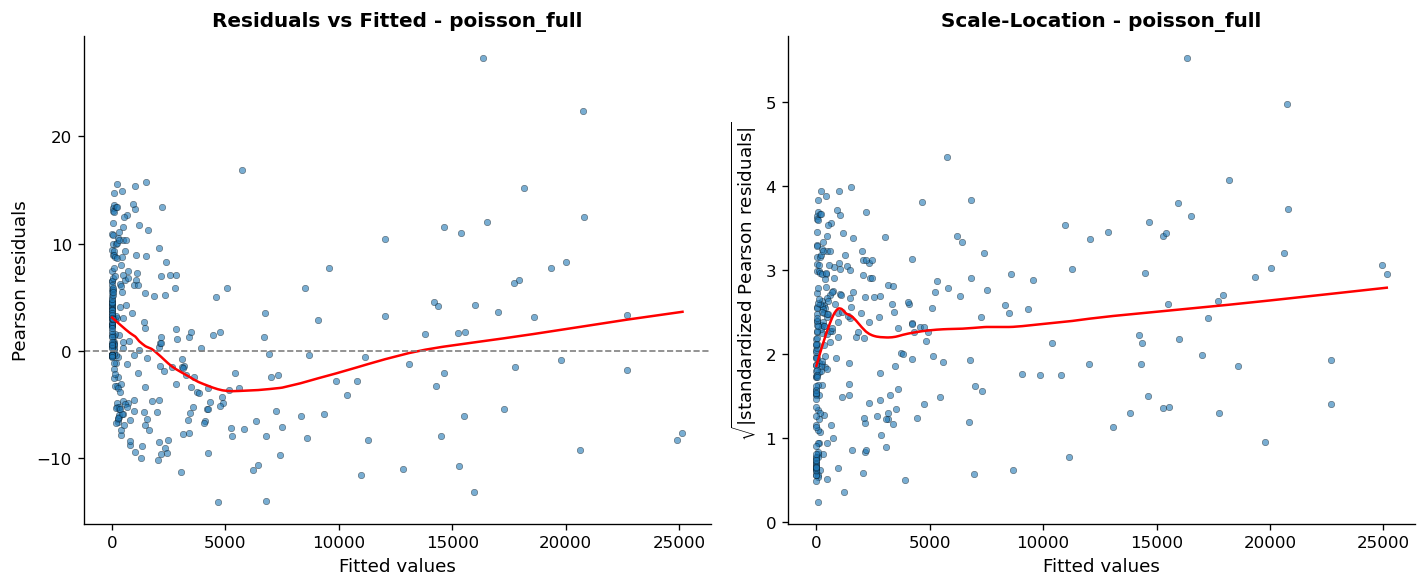

In [29]:
fitted = poisson_full.fittedvalues
pearson_resid = poisson_full.resid_pearson
std_resid = influence.resid_studentized
sqrt_abs_resid = np.sqrt(np.abs(std_resid))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

smooth1 = lowess(pearson_resid, fitted, frac=0.6)
axes[0].scatter(fitted, pearson_resid, s=15, alpha=0.6, edgecolor='k', linewidth=0.3)
axes[0].plot(smooth1[:, 0], smooth1[:, 1], color='red', linewidth=1.5)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Pearson residuals')
axes[0].set_title('Residuals vs Fitted - poisson_full')

smooth2 = lowess(sqrt_abs_resid, fitted, frac=0.6)
axes[1].scatter(fitted, sqrt_abs_resid, s=15, alpha=0.6, edgecolor='k', linewidth=0.3)
axes[1].plot(smooth2[:, 0], smooth2[:, 1], color='red', linewidth=1.5)
axes[1].set_xlabel('Fitted values')
axes[1].set_ylabel(r'$\sqrt{|\mathrm{standardized\ Pearson\ residuals}|}$')
axes[1].set_title('Scale-Location - poisson_full')

plt.tight_layout()
plt.show()

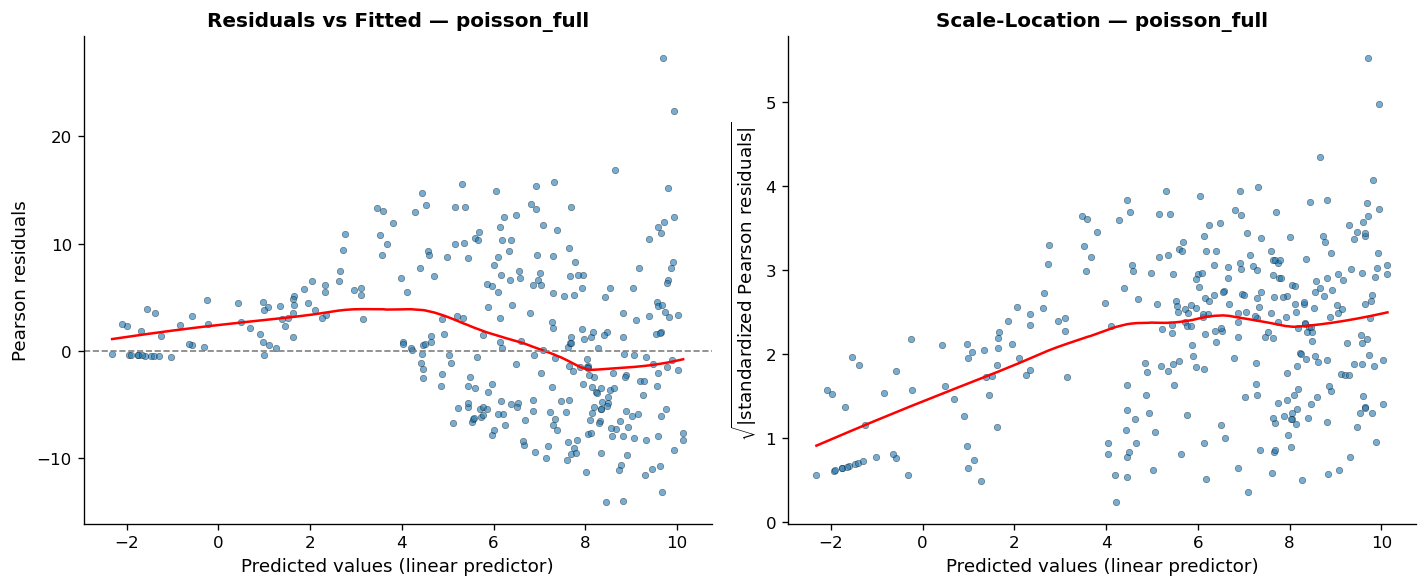

In [34]:
# eta = linear predictor (log scale), matches R's default predict()
eta = poisson_full.predict(which="linear")
pearson_resid = poisson_full.resid_pearson
std_resid = influence.resid_studentized
sqrt_abs_resid = np.sqrt(np.abs(std_resid))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

smooth1 = lowess(pearson_resid, eta, frac=0.6)
axes[0].scatter(eta, pearson_resid, s=15, alpha=0.6, edgecolor='k', linewidth=0.3)
axes[0].plot(smooth1[:, 0], smooth1[:, 1], color='red', linewidth=1.5)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted values (linear predictor)')
axes[0].set_ylabel('Pearson residuals')
axes[0].set_title('Residuals vs Fitted — poisson_full')

smooth2 = lowess(sqrt_abs_resid, eta, frac=0.6)
axes[1].scatter(eta, sqrt_abs_resid, s=15, alpha=0.6, edgecolor='k', linewidth=0.3)
axes[1].plot(smooth2[:, 0], smooth2[:, 1], color='red', linewidth=1.5)
axes[1].set_xlabel('Predicted values (linear predictor)')
axes[1].set_ylabel(r'$\sqrt{|\mathrm{standardized\ Pearson\ residuals}|}$')
axes[1].set_title('Scale-Location — poisson_full')

plt.tight_layout()
plt.show()

The residuals vs. fitted plot shows the smoother deviating from zero in
the middle range of fitted values (roughly 3–8 on the log scale),
indicating that the structural (mean) part of the model is
misspecified.

The scale-location plot shows a clearly increasing trend rather than
the flat line expected under correct specification, indicating
heteroskedasticity: the standardized residuals grow with the fitted
value, meaning the assumed mean-variance relationship is not accurately
characterised. Since quasi-Poisson only rescales standard errors by a
single constant dispersion factor, it cannot fix a mean-variance
relationship that itself changes with the fitted value, this motivates
moving to the negative binomial model, which models a genuinely
different variance function, $\text{Var}(D_i) = \mu_i + \mu_i^2/\theta$.

### Fitting the negative binomial model

The negative binomial distribution offers a genuine likelihood-based
alternative to quasi-Poisson, rather than post-hoc rescaling standard
errors, it directly models

$$
\text{Var}(D_i \mid \mathbf{x}_i) = \mu_i + \frac{\mu_i^2}{\theta},
$$

so the variance is allowed to grow faster than the mean, controlled by
the dispersion parameter $\theta$ (with $\theta \to \infty$ recovering
the Poisson case). Unlike quasi-Poisson's single constant dispersion
factor, this variance function changes with $\mu_i$ itself, which is
exactly the kind of pattern the scale-location plot above showed was
missing from `poisson_full`.

$\theta$ and the regression coefficients are estimated jointly by
maximum likelihood. In statsmodels, this is done via the discrete MLE
interface (`negativebinomial`), which estimates $\alpha = 1/\theta$
directly; the model is then refit through the `GLM` interface at the
estimated $\alpha$ to access the same influence diagnostics used above.

In [30]:
negbin_mle = smf.negativebinomial(
    formula='deaths ~ sex + diabetes + C(agegrp) + period',
    data=dmdk, offset=np.log(dmdk['pyar'])
).fit(maxiter=200)

estimated_alpha = negbin_mle.params['alpha']
estimated_theta = 1 / estimated_alpha
print(f"Estimated theta: {estimated_theta:.3f}")

negbin_mle.summary()


Optimization terminated successfully.
         Current function value: 6.469721
         Iterations: 24
         Function evaluations: 29
         Gradient evaluations: 29
Estimated theta: 16.152


<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:                 deaths   No. Observations:                  320
Model:               NegativeBinomial   Df Residuals:                      295
Method:                           MLE   Df Model:                           24
Date:                Mon, 27 Jul 2026   Pseudo R-squ.:                  0.2483
Time:                        21:25:58   Log-Likelihood:                -2070.3
converged:                       True   LL-Null:                       -2754.1
Covariance Type:            nonrobust   LLR p-value:                4.330e-274
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -8.4495      0.096    -88.122      0.000      -8.637      -8.262
sex[T.M]                0.4283      0.031     13.873      0.000       0.368       0.489
diabetes[T.Yes]         0.9227      0.033     27.811      0.000       0.858       0.988
C(agegrp)[T.11-15]     -0.4611      0.131     -3.515      0.000      -0.718      -0.204
C(agegrp)[T.16-20]      0.5576      0.125      4.453      0.000       0.312       0.803
C(agegrp)[T.21-25]      0.8145      0.124      6.575      0.000       0.572       1.057
C(agegrp)[T.26-30]      1.0589      0.122      8.695      0.000       0.820       1.298
C(agegrp)[T.31-35]      1.4348      0.118     12.159      0.000       1.204       1.666
C(agegrp)[T.36-40]      1.8422      0.115     15.992      0.000       1.616       2.068
C(agegrp)[T.41-45]      2.3125      0.114     20.348      0.000       2.090       2.535
C(agegrp)[T.46-50]      2.7104      0.113     24.052      0.000       2.490       2.931
C(agegrp)[T.51-55]      3.1153      0.112     27.770      0.000       2.895       3.335
C(agegrp)[T.56-60]      3.4905      0.112     31.197      0.000       3.271       3.710
C(agegrp)[T.6-10]      -0.8776      0.133     -6.608      0.000      -1.138      -0.617
C(agegrp)[T.61-65]      3.8985      0.112     34.905      0.000       3.680       4.117
C(agegrp)[T.66-70]      4.3151      0.112     38.692      0.000       4.097       4.534
C(agegrp)[T.71-75]      4.7698      0.111     42.812      0.000       4.551       4.988
C(agegrp)[T.76-80]      5.2547      0.111     47.210      0.000       5.037       5.473
C(agegrp)[T.81-85]      5.7526      0.111     51.727      0.000       5.535       5.971
C(agegrp)[T.86-90]      6.2673      0.111     56.377      0.000       6.049       6.485
C(agegrp)[T.91-95]      6.7710      0.111     60.913      0.000       6.553       6.989
C(agegrp)[T.96-100]     7.1835      0.111     64.491      0.000       6.965       7.402
period[T.2001-2005]    -0.1184      0.043     -2.726      0.006      -0.203      -0.033
period[T.2006-2010]    -0.2821      0.044     -6.485      0.000      -0.367      -0.197
period[T.2011-2015]    -0.4924      0.043    -11.346      0.000      -0.577      -0.407
alpha                   0.0619      0.006     10.664      0.000       0.051       0.073
=======================================================================================
"""

In [31]:
negbin_full = smf.glm(
    formula='deaths ~ sex + diabetes + C(agegrp) + period', data=dmdk,
    family=sm.families.NegativeBinomial(alpha=estimated_alpha),
    offset=np.log(dmdk['pyar'])
).fit()

influence_nb = negbin_full.get_influence()
dmdk['cooks_d_nb'] = influence_nb.cooks_distance[0]
dmdk.sort_values('cooks_d_nb', ascending=False).head(3)

,diabetes,sex,agegrp,period,deaths,pyar,age,cooks_d,cooks_d_nb
159,No,F,96-100,2011-2015,7020,22697.746064,97.5,3.729310,0.076798
155,No,F,91-95,2011-2015,19852,102464.212868,93.0,9.415763,0.055362
184,Yes,M,31-35,1996-2000,59,9243.197125,33.0,0.014006,0.040372


Question: does the negative binomial model resolve the problems
identified in `poisson_full`? We check with the same two diagnostic
plots, residuals vs. fitted for the structural part, scale-location for
the random part.

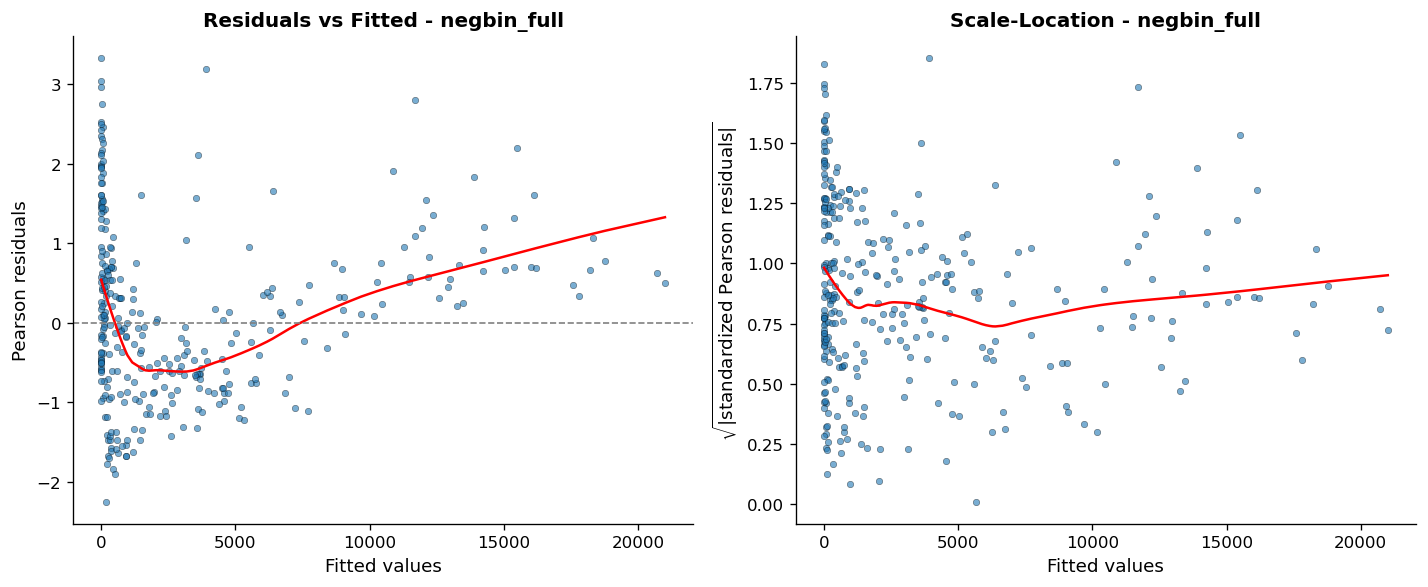

In [33]:
fitted_nb = negbin_full.fittedvalues
pearson_resid_nb = negbin_full.resid_pearson
std_resid_nb = influence_nb.resid_studentized
sqrt_abs_resid_nb = np.sqrt(np.abs(std_resid_nb))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

smooth1 = lowess(pearson_resid_nb, fitted_nb, frac=0.6)
axes[0].scatter(fitted_nb, pearson_resid_nb, s=15, alpha=0.6, edgecolor='k', linewidth=0.3)
axes[0].plot(smooth1[:, 0], smooth1[:, 1], color='red', linewidth=1.5)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Pearson residuals')
axes[0].set_title('Residuals vs Fitted - negbin_full')

smooth2 = lowess(sqrt_abs_resid_nb, fitted_nb, frac=0.6)
axes[1].scatter(fitted_nb, sqrt_abs_resid_nb, s=15, alpha=0.6, edgecolor='k', linewidth=0.3)
axes[1].plot(smooth2[:, 0], smooth2[:, 1], color='red', linewidth=1.5)
axes[1].set_xlabel('Fitted values')
axes[1].set_ylabel(r'$\sqrt{|\mathrm{standardized\ Pearson\ residuals}|}$')
axes[1].set_title('Scale-Location - negbin_full')

plt.tight_layout()
plt.show()

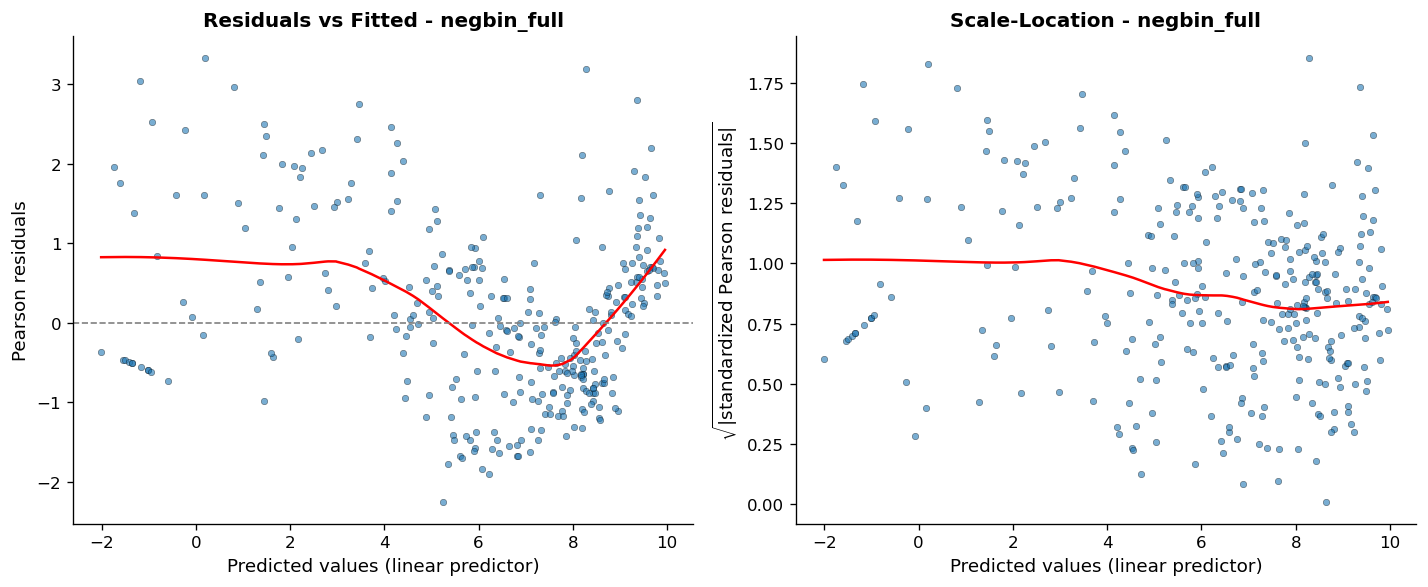

In [36]:
eta_nb = negbin_full.predict(which="linear")
pearson_resid_nb = negbin_full.resid_pearson
std_resid_nb = influence_nb.resid_studentized
sqrt_abs_resid_nb = np.sqrt(np.abs(std_resid_nb))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

smooth1 = lowess(pearson_resid_nb, eta_nb, frac=0.6)
axes[0].scatter(eta_nb, pearson_resid_nb, s=15, alpha=0.6, edgecolor='k', linewidth=0.3)
axes[0].plot(smooth1[:, 0], smooth1[:, 1], color='red', linewidth=1.5)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted values (linear predictor)')
axes[0].set_ylabel('Pearson residuals')
axes[0].set_title('Residuals vs Fitted - negbin_full')

smooth2 = lowess(sqrt_abs_resid_nb, eta_nb, frac=0.6)
axes[1].scatter(eta_nb, sqrt_abs_resid_nb, s=15, alpha=0.6, edgecolor='k', linewidth=0.3)
axes[1].plot(smooth2[:, 0], smooth2[:, 1], color='red', linewidth=1.5)
axes[1].set_xlabel('Predicted values (linear predictor)')
axes[1].set_ylabel(r'$\sqrt{|\mathrm{standardized\ Pearson\ residuals}|}$')
axes[1].set_title('Scale-Location - negbin_full')

plt.tight_layout()
plt.show()

The scale-location plot now shows a flat smoother (aside from a small,
ignorable downward drift), confirming that the negative binomial's
extra dispersion parameter has resolved the heteroskedasticity: the
random part of the model is now well characterised.

The residuals-vs-fitted plot, however, still shows the smoother
deviating from zero, the structural (mean) part of the model remains
misspecified. This is expected: changing distributional family fixes
the variance assumption, not the functional form of the linear
predictor. Fixing this requires modifying the model's structure itself,
motivating an interaction term in the next section.

### Fixing the structural problem: adding an interaction

Both `poisson_full` and `negbin_full` showed the same persistent
problem in their residuals-vs-fitted plots, evidence that the
*structural* part of the model, not the distributional family, is
misspecified. Changing the distribution (Poisson → negative binomial)
only ever fixes the variance assumption; it cannot fix a wrongly
specified mean structure, since $\theta$ enters only through the
variance function, not $\eta_i$.

Returning to Figure 1 for the source of the problem: if the effect of
diabetes on mortality were constant across age, the diabetic and
non-diabetic curves would stay a constant vertical distance apart on
the log scale, i.e. parallel. Instead, the gap visibly narrows with
age, the excess mortality risk from diabetes is proportionally much
larger in younger subgroups than older ones. A model with only additive
main effects for $\texttt{diabetes}$ and $\texttt{agegrp}$ cannot
represent this, since it forces the diabetes effect to be exactly the
same log rate ratio at every age.

The fix is an interaction term between $\texttt{diabetes}$ and
$\texttt{agegrp}$, allowing the diabetes effect to vary freely across
age groups:
\begin{align*}
\texttt{negbin\_interaction}: \quad \log(\mu_i) &= \beta_0 \\
&\quad + \beta_{\texttt{sex}} \cdot \mathbf{1}(\texttt{sex}_i=\texttt{M}) \\
&\quad + \sum_{k=2}^{4}\beta_{p_k}\cdot\mathbf{1}(\texttt{period}_i=k) \\
&\quad + \sum_{j=2}^{20}\alpha_j\cdot\mathbf{1}(\texttt{agegrp}_i=j) \\
&\quad + \beta_d\cdot\mathbf{1}(\texttt{diabetes}_i=\texttt{Yes}) \\
&\quad + \sum_{j=2}^{20}\gamma_j\cdot\mathbf{1}(\texttt{diabetes}_i=\texttt{Yes})\cdot\mathbf{1}(\texttt{agegrp}_i=j) \\
&\quad + \log(\texttt{pyar}_i),
\end{align*}
where each $\gamma_j$ allows the diabetes log rate ratio to differ by
age group.

In [37]:
negbin_int_mle = smf.negativebinomial(
    formula='deaths ~ sex + period + diabetes*C(agegrp)',
    data=dmdk, offset=np.log(dmdk['pyar'])
).fit(maxiter=200, method='bfgs')

alpha_int = negbin_int_mle.params['alpha']
theta_int = 1 / alpha_int
print(f"Estimated theta: {theta_int:.2f}")

negbin_int_mle.summary()

Optimization terminated successfully.
         Current function value: 5.818957
         Iterations: 60
         Function evaluations: 73
         Gradient evaluations: 73
Estimated theta: 76.70


<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:                 deaths   No. Observations:                  320
Model:               NegativeBinomial   Df Residuals:                      276
Method:                           MLE   Df Model:                           43
Date:                Mon, 27 Jul 2026   Pseudo R-squ.:                  0.3239
Time:                        21:37:19   Log-Likelihood:                -1862.1
converged:                       True   LL-Null:                       -2754.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
=======================================================================================================
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              -8.4577      0.049   -171.406      0.000      -8.554      -8.361
sex[T.M]                                0.4240      0.015     28.509      0.000       0.395       0.453
period[T.2001-2005]                    -0.1341      0.021     -6.406      0.000      -0.175      -0.093
period[T.2006-2010]                    -0.2972      0.021    -14.186      0.000      -0.338      -0.256
period[T.2011-2015]                    -0.4987      0.021    -23.848      0.000      -0.540      -0.458
diabetes[T.Yes]                         1.6519      0.504      3.277      0.001       0.664       2.640
C(agegrp)[T.11-15]                     -0.5176      0.071     -7.276      0.000      -0.657      -0.378
C(agegrp)[T.16-20]                      0.4923      0.066      7.514      0.000       0.364       0.621
C(agegrp)[T.21-25]                      0.6650      0.065     10.246      0.000       0.538       0.792
C(agegrp)[T.26-30]                      0.7948      0.064     12.328      0.000       0.668       0.921
C(agegrp)[T.31-35]                      1.1055      0.064     17.340      0.000       0.981       1.230
C(agegrp)[T.36-40]                      1.5402      0.063     24.390      0.000       1.416       1.664
C(agegrp)[T.41-45]                      2.0484      0.063     32.640      0.000       1.925       2.171
C(agegrp)[T.46-50]                      2.5732      0.063     41.158      0.000       2.451       2.696
C(agegrp)[T.51-55]                      3.0605      0.062     49.052      0.000       2.938       3.183
C(agegrp)[T.56-60]                      3.5015      0.062     56.189      0.000       3.379       3.624
C(agegrp)[T.6-10]                      -0.8765      0.074    -11.790      0.000      -1.022      -0.731
C(agegrp)[T.61-65]                      3.9585      0.062     63.576      0.000       3.836       4.081
C(agegrp)[T.66-70]                      4.4247      0.062     71.104      0.000       4.303       4.547
C(agegrp)[T.71-75]                      4.9183      0.062     79.060      0.000       4.796       5.040
C(agegrp)[T.76-80]                      5.4469      0.062     87.575      0.000       5.325       5.569
C(agegrp)[T.81-85]                      5.9877      0.062     96.274      0.000       5.866       6.110
C(agegrp)[T.86-90]                      6.5286      0.062    104.955      0.000       6.407       6.650
C(agegrp)[T.91-95]                      7.0585      0.062    113.390      0.000       6.936       7.181
C(agegrp)[T.96-100]                     7.4933      0.063    119.833      0.000       7.371       7.616
diabetes[T.Yes]:C(agegrp)[T.11-15]      0.1344      0.567      0.237      0.813      -0.976       1.245
diabetes[T.Yes]:C(agegrp)[T.16-20]     -0.2626      0.531     -0.495      0.621      -1.303       0.778
diabetes[T.Yes]:C(agegrp)[T.21-25]     -0.1118      0.520     -0.215      0.830      -1.132       0.908
diabetes[T.Yes]:C

In [38]:
negbin_interaction = smf.glm(
    formula='deaths ~ sex + period + diabetes*C(agegrp)', data=dmdk,
    family=sm.families.NegativeBinomial(alpha=alpha_int),
    offset=np.log(dmdk['pyar'])
).fit()

influence_int = negbin_interaction.get_influence()

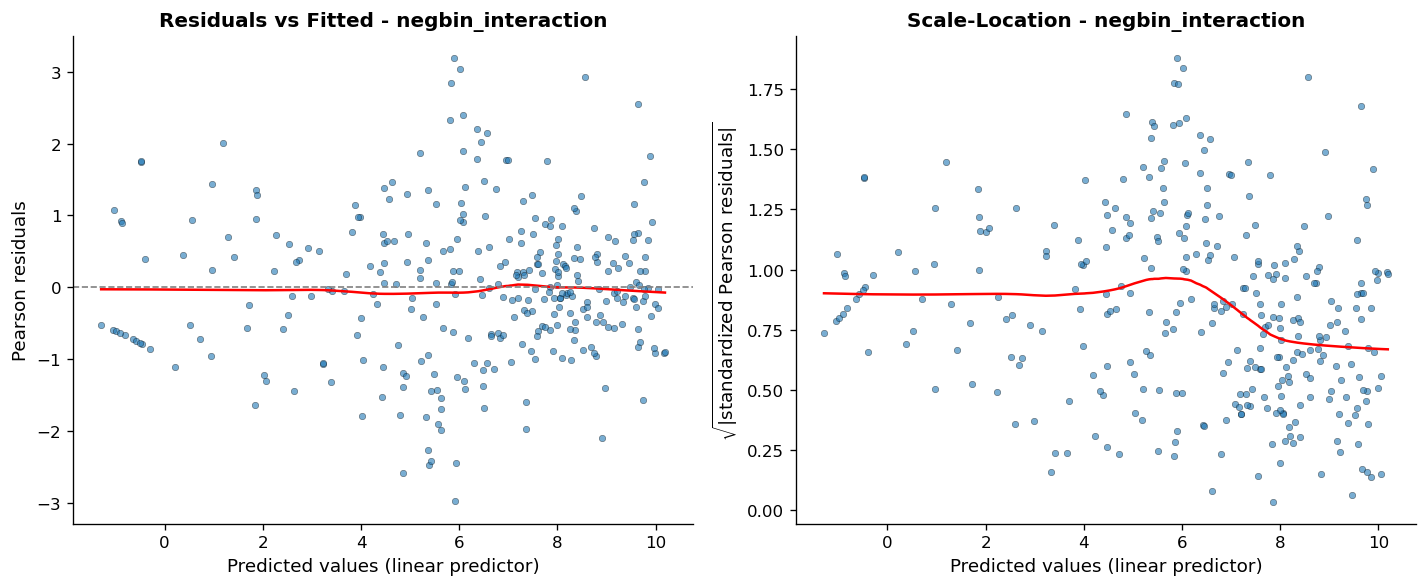

In [40]:
eta_int = negbin_interaction.predict(which="linear")
pearson_resid_int = negbin_interaction.resid_pearson
std_resid_int = influence_int.resid_studentized
sqrt_abs_resid_int = np.sqrt(np.abs(std_resid_int))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

smooth1 = lowess(pearson_resid_int, eta_int, frac=0.6)
axes[0].scatter(eta_int, pearson_resid_int, s=15, alpha=0.6, edgecolor='k', linewidth=0.3)
axes[0].plot(smooth1[:, 0], smooth1[:, 1], color='red', linewidth=1.5)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted values (linear predictor)')
axes[0].set_ylabel('Pearson residuals')
axes[0].set_title('Residuals vs Fitted - negbin_interaction')

smooth2 = lowess(sqrt_abs_resid_int, eta_int, frac=0.6)
axes[1].scatter(eta_int, sqrt_abs_resid_int, s=15, alpha=0.6, edgecolor='k', linewidth=0.3)
axes[1].plot(smooth2[:, 0], smooth2[:, 1], color='red', linewidth=1.5)
axes[1].set_xlabel('Predicted values (linear predictor)')
axes[1].set_ylabel(r'$\sqrt{|\mathrm{standardized\ Pearson\ residuals}|}$')
axes[1].set_title('Scale-Location - negbin_interaction')

plt.tight_layout()
plt.show()

The residuals vs. fitted plot now shows a smoother that stays close to
zero across the full range of fitted values, with no systematic
curvature. Alongside the flat scale-location plot, this confirms that
`negbin_interaction` has correctly characterised both the structural
and random parts of the model. The estimated dispersion also increases
substantially ($\hat\theta \approx 77$, versus $\approx 16$ for
`negbin_full`), consistent with the interaction term absorbing
variation that was previously left unexplained.

### Observed vs. expected total deaths

As a basic check of overall fit, we compare the total number of deaths
actually observed in Denmark over 1996–2015 to the total the model
predicts, summed across every subgroup. For a well-fitting model, these
should be close but not necessarily identical, the model is fit by
maximum likelihood on the full set of covariates, which does not
constrain the *sum* of fitted values to exactly equal the sum of
observed counts unless the model is saturated in the relevant margins.

In [41]:
mu_hat = negbin_interaction.fittedvalues  # response-scale (mu), not linear predictor

total_expected = mu_hat.sum()
total_observed = dmdk['deaths'].sum()

print(f"Total observed deaths:  {total_observed:,.0f}")
print(f"Total expected deaths:  {total_expected:,.0f}")
print(f"Difference:             {total_observed - total_expected:,.0f}")

Total observed deaths:  1,147,700
Total expected deaths:  1,147,387
Difference:             313


The observed and expected totals are close, differing by only a small
fraction of a percent, which is reassuring evidence of a well-fitting
model at the aggregate level, even though the earlier residual
diagnostics revealed some subgroup-level structure that a simple
totals comparison cannot detect.

### Deaths attributable to diabetes

To estimate the number of deaths attributable to diabetes, we construct
a counterfactual version of the population in which nobody has
diabetes, by recoding $\texttt{diabetes}$ to $\texttt{No}$ everywhere,
while keeping every other covariate ($\texttt{age}$, $\texttt{sex}$,
$\texttt{period}$, $\texttt{pyar}$) unchanged. Predicting from
`negbin_interaction` on this counterfactual population gives the
expected deaths if everyone had experienced the general population's
(non-diabetic) mortality rates. The difference between the model's
actual fitted deaths and this counterfactual is the estimated number of
deaths attributable to diabetes:

$$
\text{Attributable deaths} = \sum_i \hat\mu_i - \sum_i \hat\mu_i^{(0)},
$$

where $\hat\mu_i^{(0)}$ denotes the fitted value for subgroup $i$ under
the counterfactual with $\texttt{diabetes}_i = \texttt{No}$.

In [42]:
dmdk_counterfactual = dmdk.copy()
dmdk_counterfactual['diabetes'] = 'No'

mu_hat_nodb = negbin_interaction.predict(dmdk_counterfactual,
                                          offset=np.log(dmdk_counterfactual['pyar']))

attributable_deaths = mu_hat.sum() - mu_hat_nodb.sum()
print(f"Deaths attributable to diabetes: {attributable_deaths:,.0f}")

# alternative: using observed totals as the reference, rather than fitted mu_hat
attributable_deaths_obs = total_observed - mu_hat_nodb.sum()
print(f"(using observed totals as reference: {attributable_deaths_obs:,.0f})")

Deaths attributable to diabetes: 73,750
(using observed totals as reference: 74,063)


In [43]:
fraction_attributable = attributable_deaths / mu_hat.sum()
print(f"Fraction of deaths attributable to diabetes: {fraction_attributable:.4f} ({fraction_attributable*100:.2f}%)")

Fraction of deaths attributable to diabetes: 0.0643 (6.43%)


Diabetes is estimated to be responsible for a substantial share of
deaths in Denmark over this period, underscoring its importance as a
cause of death at the population level, despite diabetes itself rarely
appearing as the direct cause listed on a death certificate; its
contribution operates through cardiovascular disease, kidney failure,
and related complications baked into the elevated mortality rate.

# Diabetes and Mortality in Denmark: A Generalized Linear Modelling Approach

### Summary

Using two decades (1996–2015) of aggregated Danish population mortality
data, this project models the effect of diabetes on death rates while
adjusting for age, sex, and calendar period. Starting from a Poisson
regression baseline, diagnostic checks reveal substantial overdispersion
and a misspecified mean structure; both are resolved by moving to a
negative binomial model with a $\texttt{diabetes} \times \texttt{agegrp}$
interaction, which captures the empirical finding that diabetes' relative
impact on mortality risk is largest in younger age groups and diminishes
with age. The final model estimates that diabetes was responsible for
approximately **74,000 deaths** in Denmark over the study period, around
**6.4% of all deaths**, underscoring its significance as a population-level
cause of mortality despite rarely being the immediate cause recorded on a
death certificate.

### Conclusion

This project set out to quantify the effect of diabetes on mortality in
Denmark, and to estimate its population-level burden. The modelling
process followed a standard progression for over-dispersed count data:

1. **Poisson regression** (`poisson_full`) established a baseline,
   confirming that mortality varies strongly and non-linearly with age,
   and that women have significantly lower death rates than men after
   adjustment (rate ratio $\approx 0.68$). Diagnostics, however, revealed
   clear overdispersion: the variance of deaths within subgroups
   exceeded what the Poisson distribution allows, and quasi-Poisson
   standard errors confirmed a dispersion factor of roughly 53.

2. **Negative binomial regression** (`negbin_full`) replaced the fixed
   Poisson dispersion with an estimated parameter $\theta$, resolving
   the heteroskedasticity seen in the scale-location plot. The
   residuals-vs-fitted plot, however, still showed a systematic pattern,
   evidence that the *mean* structure, not just the variance, was
   misspecified.

3. **Adding an interaction** between $\texttt{diabetes}$ and
   $\texttt{agegrp}$ (`negbin_interaction`) resolved this remaining
   problem. This was motivated directly by Figure 1, which showed the
   gap between diabetic and non-diabetic mortality narrowing with age,
   a pattern a model with only additive effects cannot represent. With
   the interaction included, both diagnostic plots showed the desired
   flat behaviour, and the estimated dispersion increased substantially
   ($\theta \approx 77$ vs. $\approx 16$), indicating that much of the
   previously unexplained variation was in fact structured, age-varying
   diabetes effect rather than genuine overdispersion.

4. **Attributable deaths.** Using `negbin_interaction` to construct a
   counterfactual population without diabetes, an estimated 73,750–74,063
   deaths (depending on reference point) in Denmark between 1996 and 2015
   are attributable to diabetes, around 6.4% of all deaths in the
   period. This is a substantial burden for a disease that is rarely
   itself listed as a direct cause of death, reflecting its role as a
   driver of cardiovascular disease, renal failure, and other fatal
   complications.

Methodologically, this project illustrates a broader point about GLM
diagnostics: distributional choice (Poisson vs. negative binomial) and
structural specification (which covariates and interactions to include)
address different failure modes, and diagnostic plots targeting each
part separately are necessary to identify which is at fault. Fitting a
richer distribution alone does not fix a misspecified mean, just as
adding covariates alone does not fix an incorrect variance assumption.